<a href="https://colab.research.google.com/github/Herpsime/gdsc_study_session_ML_g1/blob/main/news_neural_net/notebook/FakeNews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle torch scikit-learn pandas numpy matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [3]:
import torch
import torch.nn as nn
import torchvision
import torch.optim as optim
import torchvision.transforms as transforms

In [4]:
url = 'https://raw.githubusercontent.com/lutzhamel/fake-news/master/data/fake_or_real_news.csv'

In [5]:
data = pd.read_csv(url)
data = data[['title', 'label']].dropna()
data['label'] = data['label'].map({'FAKE': 1, 'REAL': 0}).astype(np.float32)

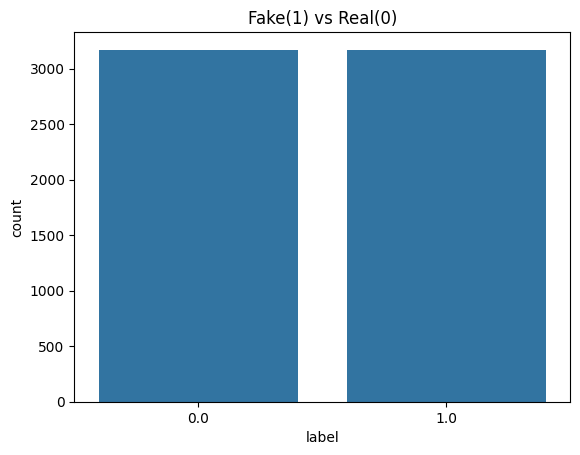

In [6]:
data.shape
data['label'].value_counts()
sns.countplot(x='label', data=data)
plt.title('Fake(1) vs Real(0)')
plt.show()

In [7]:
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(data['title']).toarray()
y = data['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (5068, 5000), Test: (1267, 5000)


In [8]:
from torch.utils.data import Dataset, DataLoader, TensorDataset

In [9]:
transform = transforms.ToTensor()

train_dataset= torchvision.datasets.MNIST(
    root = "./data",
    train= True,
    download= True,
    transform = transform
)
test_dataset= torchvision.datasets.MNIST(
    root = "./data",
    train= False,
    transform = transform
)



train_loader = torch.utils.data.DataLoader(
    dataset = train_dataset,
    batch_size = 64,
    shuffle = True
)
teat_loader = torch.utils.data.DataLoader(
    dataset = test_dataset,
    batch_size = 64,
)

In [10]:
class FakeNewsNet(nn.Module):
    def __init__(self, input_size):
        super(FakeNewsNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


X = data['title']
y = data['label']

vectorizer = TfidfVectorizer(max_features=5000)
X_vectorized = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)


input_size = X_train.shape[1]
model = FakeNewsNet(input_size)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(input_size)
sum(p.numel() for p in model.parameters())

5000


2733057

In [11]:
epochs = 15
train_losses, train_accs = [], []
test_losses, test_accs = [], []


X_train_tensor = torch.from_numpy(X_train.toarray()).float()
y_train_tensor = torch.from_numpy(y_train.to_numpy()).float()
X_test_tensor = torch.from_numpy(X_test.toarray()).float()
y_test_tensor = torch.from_numpy(y_test.to_numpy()).float()


train_dataset_fakenews = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset_fakenews = TensorDataset(X_test_tensor, y_test_tensor)


train_loader = DataLoader(train_dataset_fakenews, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset_fakenews, batch_size=64, shuffle=False)

for epoch in range(epochs):

    model.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs).squeeze()
        loss = criterion(outputs, labels.squeeze())
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        predicted = (outputs > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels.squeeze()).sum().item()


    model.eval()
    test_loss = 0.0
    correct_test, total_test = 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels.squeeze())
            test_loss += loss.item()
            predicted = (outputs > 0.5).float()
            total_test += labels.size(0)
            correct_test += (predicted == labels.squeeze()).sum().item()

In [12]:
    train_losses.append(running_loss / len(train_loader))
    train_accs.append(correct_train / total_train)
    test_losses.append(test_loss / len(test_loader))
    test_accs.append(correct_test / total_test)

    print(f'Epoch {epoch+1:2d}: Train={train_accs[-1]:.3f}, Test={test_accs[-1]:.3f}')



Epoch 15: Train=1.000, Test=0.789


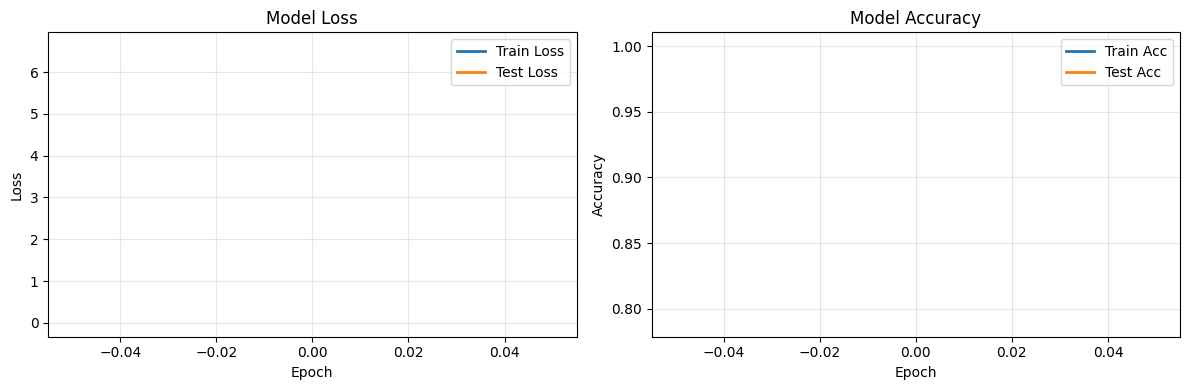

In [16]:

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(test_losses, label='Test Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc', linewidth=2)
plt.plot(test_accs, label='Test Acc', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [14]:
print(f"Final Test Accuracy: {test_accs[-1]:.4f}")

Final Test Accuracy: 0.7893


In [15]:
torch.save(model.state_dict(), 'fake_news_model_10epochs.pth')

In [18]:
def predict_news(headline):
    model.eval()
    vec = vectorizer.transform([headline]).toarray()
    X_t = torch.from_numpy(vec).float()
    pred = model(X_t).item()
    return 'Real News' if pred < 0.5 else 'Fake News'
print(predict_news("Aliens landed in NY"))

Fake News
